# 1.2 — Outlier Detection

## What is an Outlier and Why Does it Matter?

An **outlier** is a value that is very different from most other values in the same column.  
For example, if most patients have a pain score between 0 and 10, but one row has a score of 99, that 99 is an outlier.

**Why do we care?**  
- Machine learning models learn patterns from data. If a column contains a value of 999 (often used to mark "missing" in old datasets), the model might learn the wrong patterns.
- Outliers can drag the model's predictions far from reality.
- Cleaning or flagging outliers before modelling usually improves accuracy significantly.

## Two Plain-English Methods Used Here

### Method 1 — IQR Rule (The "Middle 50%" Rule)
1. Sort all values in a column from smallest to largest.
2. Find the value at the 25th percentile (Q1) and the 75th percentile (Q3).  
   These mark where the **middle 50% of rows** sit.
3. The spread of that middle band is called the **IQR** = Q3 − Q1.
4. Anything **below** Q1 − 1.5 × IQR or **above** Q3 + 1.5 × IQR is flagged as an outlier.

This method is robust — it ignores the extremes when deciding what is "normal".

### Method 2 — Z-Score Rule (The "How Many Standard Deviations Away" Rule)
1. Calculate the average (mean) and spread (standard deviation) of a column.
2. For each value, compute how many standard deviations it is away from the mean — that's the **Z-score**.
3. A Z-score above **3** or below **−3** is flagged as an outlier (covers ~99.7% of a normal distribution).

**Use both together**: if a value is flagged by *both* methods, it is almost certainly a genuine extreme value that deserves attention.

In [1]:
import polars as pl
import numpy as np
import pandas as pd
from pathlib import Path


%matplotlib inline

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', 120)

In [2]:
DATA_PATH = Path('./data/interim/1.1-Reduced.parquet')
df_raw = pl.read_parquet(DATA_PATH)

print(f"Rows   : {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")

Rows   : 139,236
Columns: 82


In [3]:
# Replace sentinel missing-value codes with null BEFORE outlier detection.
# In this dataset:
#   - 9 and 999 are used as "unknown / not answered" codes in numeric columns
#   - "*"        is used as a missing/suppressed marker in text/categorical columns
# None of these are real measurements and must not be treated as extreme values.

MISSING_CODES_NUMERIC = [9, 999]
MISSING_CODES_STRING  = ["*", ""]

numeric_dtypes_pl = [
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
]
string_dtypes_pl = [pl.Utf8, pl.String, pl.Categorical]

# ── Numeric columns ──────────────────────────────────────────────────────────
numeric_cols_to_clean = [
    c for c in df_raw.columns
    if df_raw[c].dtype in numeric_dtypes_pl
    and any(
        code in df_raw[c].drop_nulls().unique().to_list()
        for code in MISSING_CODES_NUMERIC
    )
]

print(f"Numeric columns where 9 or 999 → null ({len(numeric_cols_to_clean)}):")
for c in numeric_cols_to_clean:
    vals = sorted(df_raw[c].drop_nulls().unique().to_list())
    print(f"  {c!r}  unique values before: {vals[:15]}")

df_raw = df_raw.with_columns([
    pl.when(pl.col(c).is_in(MISSING_CODES_NUMERIC))
      .then(None)
      .otherwise(pl.col(c))
      .alias(c)
    for c in numeric_cols_to_clean
])

# ── String / categorical columns ─────────────────────────────────────────────
string_cols_to_clean = [
    c for c in df_raw.columns
    if df_raw[c].dtype in string_dtypes_pl
    and any(
        code in df_raw[c].drop_nulls().unique().cast(pl.Utf8).to_list()
        for code in MISSING_CODES_STRING
    )
]

print(f"\nText columns where '*' or '' → null ({len(string_cols_to_clean)}):")
for c in string_cols_to_clean:
    vals = sorted(df_raw[c].drop_nulls().cast(pl.Utf8).unique().to_list())
    print(f"  {c!r}  unique values before: {vals[:15]}")

df_raw = df_raw.with_columns([
    pl.when(pl.col(c).cast(pl.Utf8).is_in(MISSING_CODES_STRING))
      .then(None)
      .otherwise(pl.col(c))
      .alias(c)
    for c in string_cols_to_clean
])

# ── Summary ───────────────────────────────────────────────────────────────────
all_cleaned = numeric_cols_to_clean + string_cols_to_clean
print(f"\nDone. Total null counts across all cleaned columns:")
print(df_raw.select(all_cleaned).null_count())


Numeric columns where 9 or 999 → null (67):
  'Pre-Op Q Assisted'  unique values before: [1, 2, 9]
  'Pre-Op Q Symptom Period'  unique values before: [1, 2, 3, 4, 9]
  'Pre-Op Q Previous Surgery'  unique values before: [1, 2, 9]
  'Pre-Op Q Living Arrangements'  unique values before: [1, 2, 3, 4, 9]
  'Pre-Op Q Disability'  unique values before: [1, 2, 9]
  'Heart Disease'  unique values before: [1, 9]
  'High Bp'  unique values before: [1, 9]
  'Stroke'  unique values before: [1, 9]
  'Circulation'  unique values before: [1, 9]
  'Lung Disease'  unique values before: [1, 9]
  'Diabetes'  unique values before: [1, 9]
  'Kidney Disease'  unique values before: [1, 9]
  'Nervous System'  unique values before: [1, 9]
  'Liver Disease'  unique values before: [1, 9]
  'Cancer'  unique values before: [1, 9]
  'Depression'  unique values before: [1, 9]
  'Arthritis'  unique values before: [1, 9]
  'Pre-Op Q Mobility'  unique values before: [1, 2, 3, 9]
  'Pre-Op Q Self-Care'  unique values bef

## Step 1 — Quick Value Summary per Feature

Before looking for outliers, let's get a feel for every column:  
minimum, maximum, mean, and how many nulls it has.  
This table is purely informational — it helps you spot obvious issues at a glance.

In [4]:
# Separate numeric columns from categorical/string columns
numeric_dtypes = [
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
]

numeric_cols = [c for c in df_raw.columns if df_raw[c].dtype in numeric_dtypes]
cat_cols     = [c for c in df_raw.columns if df_raw[c].dtype in (pl.Utf8, pl.Categorical, pl.String)]

print(f"Numeric columns : {len(numeric_cols)}")
print(f"Text columns    : {len(cat_cols)}")
print(f"Text columns    : {cat_cols}")

Numeric columns : 76
Text columns    : 6
Text columns    : ['Provider Code', 'Procedure', 'Year', 'Age Band', 'Gender', 'CSVYear']


In [5]:
# ── Build a quick summary for every numeric column ──────────────────────────
rows = []
for c in numeric_cols:
    series = df_raw[c].drop_nulls()
    n_total  = df_raw.shape[0]
    n_null   = df_raw[c].null_count()
    n_valid  = len(series)
    unique_vals = series.unique().to_list()
    rows.append({
        'Column'       : c,
        'DType'        : str(df_raw[c].dtype),
        'N_Total'      : n_total,
        'N_Null'       : n_null,
        'Null_%'       : round(100 * n_null / n_total, 1),
        'N_Unique'     : len(unique_vals),
        'Min'          : series.min(),
        'Max'          : series.max(),
        'Mean'         : round(float(series.mean()), 2) if n_valid > 0 else None,
        'Median'       : series.median(),
        'Std'          : round(float(series.std()), 2)  if n_valid > 1 else None,
    })

summary_df = pd.DataFrame(rows)
print("=" * 80)
print("NUMERIC COLUMN VALUE SUMMARY")
print("=" * 80)
summary_df

NUMERIC COLUMN VALUE SUMMARY


,Column,DType,N_Total,N_Null,Null_%,N_Unique,Min,Max,Mean,Median,Std
0,Revision Flag,UInt8,139236,0,0.00,2,0.00,1.00,0.04,0.00,0.19
1,Pre-Op Q Assisted,UInt8,139236,1511,1.10,2,1.00,2.00,1.85,2.00,0.36
2,Pre-Op Q Assisted By,UInt8,139236,0,0.00,1,0.00,0.00,0.00,0.00,0.00
3,Pre-Op Q Symptom Period,UInt8,139236,1209,0.90,4,1.00,4.00,2.60,2.00,0.87
4,Pre-Op Q Previous Surgery,UInt8,139236,1042,0.70,2,1.00,2.00,1.92,2.00,0.27
5,Pre-Op Q Living Arrangements,UInt8,139236,2087,1.50,4,1.00,4.00,1.23,1.00,0.45
6,Pre-Op Q Disability,UInt8,139236,5907,4.20,2,1.00,2.00,1.49,1.00,0.50
7,Heart Disease,UInt8,139236,126185,90.60,1,1.00,1.00,1.00,1.00,0.00
8,High Bp,UInt8,139236,77666,55.80,1,1.00,1.00,1.00,1.00,0.00
9,Stroke,UInt8,139236,136933,98.30,1,1.00,1.00,1.00,1.00,0.00


## Step 2 — IQR Outlier Detection

For every numeric column we compute:

| Term | Meaning |
|------|---------|
| Q1   | Value at the 25th percentile (bottom of the middle band) |
| Q3   | Value at the 75th percentile (top of the middle band) |
| IQR  | Q3 − Q1 (width of the middle band) |
| Lower fence | Q1 − 1.5 × IQR  — observations below this are low outliers |
| Upper fence | Q3 + 1.5 × IQR  — observations above this are high outliers |

The result table is sorted from **most outliers** (highest % of rows) to least,  
so the most problematic columns appear first.

In [6]:
def iqr_outlier_summary(df: pl.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Return IQR-based outlier counts and fences for each column."""
    rows = []
    n_total = df.shape[0]

    for c in cols:
        series = df[c].drop_nulls()
        if len(series) < 4:
            continue

        q1  = float(series.quantile(0.25, interpolation='nearest'))
        q3  = float(series.quantile(0.75, interpolation='nearest'))
        iqr = q3 - q1

        if iqr == 0:
            # All values identical — zero spread, no IQR outliers possible
            rows.append({
                'Column': c,
                'Q1': q1, 'Q3': q3, 'IQR': 0,
                'Lower_Fence': q1, 'Upper_Fence': q3,
                'N_Low_Outliers': 0, 'N_High_Outliers': 0,
                'N_Total_Outliers': 0,
                'Pct_Outliers': 0.0,
                'Note': 'IQR=0 (constant column)'
            })
            continue

        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr

        n_low  = int((series < lower_fence).sum())
        n_high = int((series > upper_fence).sum())
        n_out  = n_low + n_high

        rows.append({
            'Column'          : c,
            'Q1'              : round(q1, 2),
            'Q3'              : round(q3, 2),
            'IQR'             : round(iqr, 2),
            'Lower_Fence'     : round(lower_fence, 2),
            'Upper_Fence'     : round(upper_fence, 2),
            'N_Low_Outliers'  : n_low,
            'N_High_Outliers' : n_high,
            'N_Total_Outliers': n_out,
            'Pct_Outliers'    : round(100 * n_out / n_total, 2),
            'Note'            : ''
        })

    result = pd.DataFrame(rows)
    return result.sort_values('Pct_Outliers', ascending=False).reset_index(drop=True)


iqr_summary = iqr_outlier_summary(df_raw, numeric_cols)
print("=" * 80)
print("IQR OUTLIER SUMMARY  (sorted: most outliers first)")
print("=" * 80)
iqr_summary

IQR OUTLIER SUMMARY  (sorted: most outliers first)


,Column,Q1,Q3,IQR,Lower_Fence,Upper_Fence,N_Low_Outliers,N_High_Outliers,N_Total_Outliers,Pct_Outliers,Note
0,Knee Replacement Post-Op Q Limping,3.00,4.00,1.00,1.50,5.50,16554,0,16554,11.89,
1,Pre-Op Q EQ5D Index Profile,21221.00,22222.00,1001.00,19719.50,23723.50,10792,5073,15865,11.39,
2,Knee Replacement Post-Op Q Shopping,3.00,4.00,1.00,1.50,5.50,15177,0,15177,10.90,
3,Knee Replacement Pre-Op Q Limping,0.00,1.00,1.00,-1.50,2.50,0,13883,13883,9.97,
4,Knee Replacement Post-Op Q Walking,3.00,4.00,1.00,1.50,5.50,9073,0,9073,6.52,
5,Post-Op Q EQ5D Index,0.69,1.00,0.31,0.22,1.47,8848,0,8848,6.35,
6,Knee Replacement Post-Op Q Standing,3.00,4.00,1.00,1.50,5.50,8466,0,8466,6.08,
7,Post-Op Q Sucess,1.00,2.00,1.00,-0.50,3.50,0,7638,7638,5.49,
8,Knee Replacement Post-Op Q Confidence,3.00,4.00,1.00,1.50,5.50,6218,0,6218,4.47,
9,Knee Replacement Pre-Op Q Stairs,1.00,2.00,1.00,-0.50,3.50,0,4855,4855,3.49,


## Step 3 — Z-Score Outlier Detection

For each numeric column we compute the mean and standard deviation, then flag any value whose **Z-score** is above 3 or below −3.

> **Intuition**: if an exam average is 60 and the typical spread is 10 points,  
> a Z-score of 3 means the value is 60 + 3×10 = **90** — very far from average.

Z-scores are sensitive to the mean, which itself can be pulled by extreme values.  
That's why we use **both** IQR and Z-score: columns flagged by *both* are higher priority.

In [7]:
def zscore_outlier_summary(df: pl.DataFrame, cols: list[str], threshold: float = 3.0) -> pd.DataFrame:
    """Return Z-score-based outlier counts for each column."""
    rows = []
    n_total = df.shape[0]

    for c in cols:
        series = df[c].drop_nulls()
        if len(series) < 4:
            continue

        mean = float(series.mean())
        std  = float(series.std())

        if std == 0:
            rows.append({
                'Column': c, 'Mean': round(mean, 2), 'Std': 0,
                'N_ZScore_Outliers': 0, 'Pct_ZScore_Outliers': 0.0,
                'Note': 'Std=0 (constant column)'
            })
            continue

        z_scores  = ((series - mean) / std).abs()
        n_out     = int((z_scores > threshold).sum())

        rows.append({
            'Column'             : c,
            'Mean'               : round(mean, 2),
            'Std'                : round(std, 2),
            'N_ZScore_Outliers'  : n_out,
            'Pct_ZScore_Outliers': round(100 * n_out / n_total, 2),
            'Note'               : ''
        })

    result = pd.DataFrame(rows)
    return result.sort_values('Pct_ZScore_Outliers', ascending=False).reset_index(drop=True)


zscore_summary = zscore_outlier_summary(df_raw, numeric_cols)
print("=" * 80)
print(f"Z-SCORE OUTLIER SUMMARY  (threshold = |Z| > 3, sorted: most outliers first)")
print("=" * 80)
zscore_summary

Z-SCORE OUTLIER SUMMARY  (threshold = |Z| > 3, sorted: most outliers first)


,Column,Mean,Std,N_ZScore_Outliers,Pct_ZScore_Outliers,Note
0,Pre-Op Q Mobility,1.92,0.28,11187,8.03,
1,Pre-Op Q Previous Surgery,1.92,0.27,10784,7.75,
2,Post-Op Q Readmitted,1.92,0.27,10728,7.70,
3,Post-Op Q Assisted,1.93,0.26,9854,7.08,
4,Post-Op Q Bleeding,1.93,0.26,8723,6.26,
5,Revision Flag,0.04,0.19,5274,3.79,
6,Pre-Op Q EQ5D Index Profile,23214.76,13893.51,4286,3.08,
7,Post-Op Q Further Surgery,1.97,0.17,4137,2.97,
8,Knee Replacement Post-Op Q Walking,3.34,1.00,3963,2.85,
9,Post-Op Q EQ5D Index,0.75,0.25,3481,2.50,


## Step 4 — Combined View: Flagged by BOTH Methods

A column flagged by **both** IQR and Z-score is very likely a genuine problem.  
This table shows only those columns, along with both outlier percentages.  

**How to read it**: if `Pct_Outliers` (IQR) or `Pct_ZScore_Outliers` is above ~5%, that column deserves close attention during data preparation.

In [8]:
# Merge both summaries on Column name
combined = (
    iqr_summary[['Column', 'Q1', 'Q3', 'IQR', 'Lower_Fence', 'Upper_Fence',
                  'N_Low_Outliers', 'N_High_Outliers', 'N_Total_Outliers', 'Pct_Outliers']]
    .merge(
        zscore_summary[['Column', 'Mean', 'Std', 'N_ZScore_Outliers', 'Pct_ZScore_Outliers']],
        on='Column', how='inner'
    )
)

# Flag columns detected by both methods
both_flagged = combined[
    (combined['Pct_Outliers'] > 0) & (combined['Pct_ZScore_Outliers'] > 0)
].sort_values('Pct_Outliers', ascending=False).reset_index(drop=True)

print(f"Columns flagged by BOTH IQR and Z-score: {len(both_flagged)}")
print("=" * 80)
both_flagged

Columns flagged by BOTH IQR and Z-score: 18


,Column,Q1,Q3,IQR,Lower_Fence,Upper_Fence,N_Low_Outliers,N_High_Outliers,N_Total_Outliers,Pct_Outliers,Mean,Std,N_ZScore_Outliers,Pct_ZScore_Outliers
0,Pre-Op Q EQ5D Index Profile,21221.00,22222.00,1001.00,19719.50,23723.50,10792,5073,15865,11.39,23214.76,13893.51,4286,3.08
1,Knee Replacement Pre-Op Q Limping,0.00,1.00,1.00,-1.50,2.50,0,13883,13883,9.97,0.89,1.00,1725,1.24
2,Knee Replacement Post-Op Q Walking,3.00,4.00,1.00,1.50,5.50,9073,0,9073,6.52,3.34,1.00,3963,2.85
3,Post-Op Q EQ5D Index,0.69,1.00,0.31,0.22,1.47,8848,0,8848,6.35,0.75,0.25,3481,2.50
4,Knee Replacement Post-Op Q Standing,3.00,4.00,1.00,1.50,5.50,8466,0,8466,6.08,3.08,0.90,501,0.36
5,Post-Op Q Sucess,1.00,2.00,1.00,-0.50,3.50,0,7638,7638,5.49,1.43,0.89,3055,2.19
6,Knee Replacement Post-Op Q Confidence,3.00,4.00,1.00,1.50,5.50,6218,0,6218,4.47,3.49,0.84,1707,1.23
7,Knee Replacement Pre-Op Q Kneeling,0.00,1.00,1.00,-1.50,2.50,0,4761,4761,3.42,0.81,0.86,739,0.53
8,Post-Op Q EQ5D Index Profile,11111.00,21221.00,10110.00,-4054.00,36386.00,0,2955,2955,2.12,17587.27,12939.07,2953,2.12
9,Knee Replacement Post-Op Q Score,31.00,43.00,12.00,13.00,61.00,2928,0,2928,2.10,35.97,9.38,994,0.71


## Step 5 — Extreme Value Samples

For the **top 10 most-outlier-prone columns** (by IQR %), we show what the actual extreme values look like.  
This helps you determine whether:
- The extreme values are **legitimate** (e.g. a very elderly patient).
- The extreme values are **data entry codes** (e.g. `999` = unknown) that should be treated as missing.
- The extreme values are **data quality errors** that should be removed.

In [9]:
top_cols = iqr_summary[
    iqr_summary['Pct_Outliers'] > 0
].head(10)['Column'].tolist()

for c in top_cols:
    series = df_raw[c].drop_nulls()
    q1  = float(series.quantile(0.25, interpolation='nearest'))
    q3  = float(series.quantile(0.75, interpolation='nearest'))
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    low_vals  = series.filter(series < lower_fence).unique().sort().to_list()
    high_vals = series.filter(series > upper_fence).unique().sort().to_list()

    pct = iqr_summary.loc[iqr_summary['Column'] == c, 'Pct_Outliers'].values[0]

    print(f"\n{'─'*70}")
    print(f"  Column : {c}")
    print(f"  Fences : [{lower_fence:.2f}  …  {upper_fence:.2f}]   (valid range)")
    print(f"  % Rows outside fences : {pct}%")
    print(f"  Unique LOW  outlier values : {low_vals[:20]}"   +
          (" …" if len(low_vals)  > 20 else ""))
    print(f"  Unique HIGH outlier values : {high_vals[:20]}" +
          (" …" if len(high_vals) > 20 else ""))


──────────────────────────────────────────────────────────────────────
  Column : Knee Replacement Post-Op Q Limping
  Fences : [1.50  …  5.50]   (valid range)
  % Rows outside fences : 11.89%
  Unique LOW  outlier values : [0, 1]
  Unique HIGH outlier values : []

──────────────────────────────────────────────────────────────────────
  Column : Pre-Op Q EQ5D Index Profile
  Fences : [19719.50  …  23723.50]   (valid range)
  % Rows outside fences : 11.39%
  Unique LOW  outlier values : [11111, 11112, 11113, 11119, 11121, 11122, 11123, 11129, 11131, 11132, 11133, 11139, 11191, 11192, 11193, 11199, 11211, 11212, 11213, 11219] …
  Unique HIGH outlier values : [23921, 23931, 23932, 29111, 29112, 29121, 29122, 29129, 29131, 29211, 29212, 29221, 29222, 29223, 29229, 29231, 29232, 29233, 29239, 29291] …

──────────────────────────────────────────────────────────────────────
  Column : Knee Replacement Post-Op Q Shopping
  Fences : [1.50  …  5.50]   (valid range)
  % Rows outside fences : 10.

## Step 6 — Categorical / Text Columns

Outliers in text columns are harder to define numerically, but we can still spot  
**rare categories** — values that appear in very few rows.  

A category that covers less than **0.5%** of rows is something to check:  
it might be a typo, an unexpected code, or a genuinely rare but valid entry.

In [10]:
RARE_THRESHOLD_PCT = 0.5   # flag categories covering less than 0.5% of rows

n_total = df_raw.shape[0]

cat_rows = []
for c in cat_cols:
    counts = df_raw.group_by(c).agg(pl.len().alias('count')).sort('count')
    for row in counts.iter_rows(named=True):
        pct = round(100 * row['count'] / n_total, 3)
        cat_rows.append({'Column': c, 'Value': row[c], 'Count': row['count'], 'Pct': pct,
                         'Rare': pct < RARE_THRESHOLD_PCT})

cat_df = pd.DataFrame(cat_rows)
print("=" * 80)
print(f"CATEGORICAL VALUE COUNTS  (threshold for 'Rare' = < {RARE_THRESHOLD_PCT}%)")
print("=" * 80)
cat_df

CATEGORICAL VALUE COUNTS  (threshold for 'Rare' = < 0.5%)


,Column,Value,Count,Pct,Rare
0,Provider Code,RJ7,7,0.01,True
1,Provider Code,NYW01,9,0.01,True
2,Provider Code,NT343,10,0.01,True
3,Provider Code,NT455,12,0.01,True
4,Provider Code,NT310,12,0.01,True
...,...,...,...,...,...
306,Gender,1,55749,40.04,False
307,Gender,2,74085,53.21,False
308,CSVYear,2018/19,45635,32.77,False
309,CSVYear,2017/18,45997,33.03,False


In [11]:
rare_cats = cat_df[cat_df['Rare']].sort_values(['Column', 'Pct'])
print(f"Rare categories (< {RARE_THRESHOLD_PCT}% of rows): {len(rare_cats)} entries")
print(rare_cats.to_string(index=False))

Rare categories (< 0.5% of rows): 230 entries
       Column     Value  Count  Pct  Rare
     Age Band 90 to 120     24 0.02  True
     Age Band  40 to 49    250 0.18  True
Provider Code       RJ7      7 0.01  True
Provider Code     NYW01      9 0.01  True
Provider Code     NT343     10 0.01  True
Provider Code     NT455     12 0.01  True
Provider Code     NT310     12 0.01  True
Provider Code     NFH01     13 0.01  True
Provider Code     NT30A     13 0.01  True
Provider Code     NVC0R     19 0.01  True
Provider Code     NT416     19 0.01  True
Provider Code     NT315     21 0.01  True
Provider Code     NQM01     22 0.02  True
Provider Code     NT308     25 0.02  True
Provider Code     NT241     29 0.02  True
Provider Code     NT436     29 0.02  True
Provider Code     NT211     30 0.02  True
Provider Code     NT205     31 0.02  True
Provider Code     NT406     36 0.03  True
Provider Code     NT364     37 0.03  True
Provider Code     NT409     37 0.03  True
Provider Code     NT345     38

## Step 7 — Final Priority Summary

A single ranked table of the **most problematic numeric columns**, combining IQR and Z-score flags.  

**Severity guide**:

| Outlier % | Severity | Recommended Action |
|-----------|----------|--------------------|
| > 10%     | High     | Investigate and likely clip or treat as missing |
| 2–10%     | Medium   | Review the extreme values manually |
| < 2%      | Low      | Usually safe to ignore or cap |

**Missing value codes** (like 999, 9, 99) will appear as very high outliers — they should be replaced with null before modelling, which happens in notebook `2.0-Data-Pre-Preparation`.

In [12]:
def severity(pct: float) -> str:
    if pct > 10: return 'HIGH'
    if pct > 2:  return 'MEDIUM'
    if pct > 0:  return 'LOW'
    return 'OK'

priority = combined[combined['Pct_Outliers'] > 0].copy()
priority['Severity_IQR']    = priority['Pct_Outliers'].apply(severity)
priority['Severity_ZScore'] = priority['Pct_ZScore_Outliers'].apply(severity)

# Select IQR columns first (no Min/Max yet)
priority = priority[[
    'Column',
    'Lower_Fence', 'Upper_Fence',
    'Pct_Outliers', 'Severity_IQR',
    'Pct_ZScore_Outliers', 'Severity_ZScore'
]].copy()

# Bring Min/Max from the value summary (they only exist in summary_df)
priority = priority.merge(
    summary_df[['Column', 'Min', 'Max']],
    on='Column', how='left'
)

priority = priority.sort_values('Pct_Outliers', ascending=False).reset_index(drop=True)
print("=" * 80)
print("PRIORITY OUTLIER TABLE — NUMERIC FEATURES")
print("=" * 80)
priority[[
    'Column', 'Min', 'Max', 'Lower_Fence', 'Upper_Fence',
    'Pct_Outliers', 'Severity_IQR',
    'Pct_ZScore_Outliers', 'Severity_ZScore'
]]


PRIORITY OUTLIER TABLE — NUMERIC FEATURES


,Column,Min,Max,Lower_Fence,Upper_Fence,Pct_Outliers,Severity_IQR,Pct_ZScore_Outliers,Severity_ZScore
0,Knee Replacement Post-Op Q Limping,0.00,4.00,1.50,5.50,11.89,HIGH,0.00,OK
1,Pre-Op Q EQ5D Index Profile,11111.00,99999.00,19719.50,23723.50,11.39,HIGH,3.08,MEDIUM
2,Knee Replacement Post-Op Q Shopping,0.00,4.00,1.50,5.50,10.90,HIGH,0.00,OK
3,Knee Replacement Pre-Op Q Limping,0.00,4.00,-1.50,2.50,9.97,MEDIUM,1.24,LOW
4,Knee Replacement Post-Op Q Walking,0.00,4.00,1.50,5.50,6.52,MEDIUM,2.85,MEDIUM
5,Post-Op Q EQ5D Index,-0.59,1.00,0.22,1.47,6.35,MEDIUM,2.50,MEDIUM
6,Knee Replacement Post-Op Q Standing,0.00,4.00,1.50,5.50,6.08,MEDIUM,0.36,LOW
7,Post-Op Q Sucess,1.00,5.00,-0.50,3.50,5.49,MEDIUM,2.19,MEDIUM
8,Knee Replacement Post-Op Q Confidence,0.00,4.00,1.50,5.50,4.47,MEDIUM,1.23,LOW
9,Knee Replacement Pre-Op Q Stairs,0.00,4.00,-0.50,3.50,3.49,MEDIUM,0.00,OK


## Step 8 — Priority Outlier Table: String / Categorical Features

For text columns, an "outlier" is a **rare category** — a value that appears in very few rows.  
We rank columns by their rarest category's percentage and assign a severity label.

| Rare % | Severity | What it likely means |
|--------|----------|----------------------|
| < 0.1% | HIGH     | Possible typo, data error, or suppressed code |
| 0.1–0.5% | MEDIUM | Worth reviewing — could be valid but uncommon |
| 0.5–1% | LOW     | Unusual but probably fine |

`N_Rare_Values` = how many distinct values in that column are rare.  
`Min_Pct` = the rarest single value's share of all rows (the worst case).


In [13]:
def cat_severity(min_pct: float) -> str:
    if min_pct < 0.1:  return 'HIGH'
    if min_pct < 0.5:  return 'MEDIUM'
    if min_pct < 1.0:  return 'LOW'
    return 'OK'

# Build one row per categorical column summarising its rarest values
cat_priority_rows = []
for c in cat_cols:
    col_data = cat_df[cat_df['Column'] == c].copy()
    rare     = col_data[col_data['Rare']]

    n_unique         = len(col_data)
    n_rare           = len(rare)
    n_outlier_rows   = int(rare['Count'].sum()) if n_rare > 0 else 0
    min_pct          = rare['Pct'].min()        if n_rare > 0 else None
    rare_values      = rare.sort_values('Pct')['Value'].tolist()

    cat_priority_rows.append({
        'Column'         : c,
        'N_Unique'       : n_unique,
        'N_Rare_Values'  : n_rare,
        'N_Outlier_Rows' : n_outlier_rows,
        'Pct_Outlier_Rows': round(100 * n_outlier_rows / df_raw.shape[0], 3) if n_rare > 0 else 0.0,
        'Min_Pct'        : round(min_pct, 3) if min_pct is not None else None,
        'Severity'       : cat_severity(min_pct) if min_pct is not None else 'OK',
        'Rare_Values'    : str(rare_values[:10]) + (' …' if len(rare_values) > 10 else ''),
    })

cat_priority = (
    pd.DataFrame(cat_priority_rows)
    .query('N_Rare_Values > 0')
    .sort_values('Min_Pct', ascending=True)
    .reset_index(drop=True)
)

print("=" * 80)
print("PRIORITY OUTLIER TABLE — STRING / CATEGORICAL FEATURES")
print("(sorted: rarest category first)")
print("=" * 80)
cat_priority[[
    'Column', 'N_Unique', 'N_Rare_Values', 'N_Outlier_Rows', 'Pct_Outlier_Rows',
    'Min_Pct', 'Severity', 'Rare_Values'
]]


PRIORITY OUTLIER TABLE — STRING / CATEGORICAL FEATURES
(sorted: rarest category first)


,Column,N_Unique,N_Rare_Values,N_Outlier_Rows,Pct_Outlier_Rows,Min_Pct,Severity,Rare_Values
0,Provider Code,294,228,63132,45.34,0.01,HIGH,"['RJ7', 'NYW01', 'NT343', 'NT455', 'NT310', 'N..."
1,Age Band,7,2,274,0.20,0.02,HIGH,"['90 to 120', '40 to 49']"


## Step 9 — Why Is "Age Band" Flagged as an Outlier?

`Age Band` is typically encoded as a **numeric code** (e.g. 1 = 18–35, 2 = 36–50, …, 8 = 85+).  
Because it is stored as an integer, the IQR and Z-score methods treat it as a continuous measurement and flag the extreme band codes (the very young or very old groups) as outliers.

**However, these are not real outliers** — they are valid, meaningful categories.  
The "outlier" flag arises because:

1. The distribution is **skewed** — most patients fall in a narrow middle-age range, so the tails (youngest and oldest bands) lie outside the IQR fences.
2. The codes are **ordinal labels**, not measurements; the numeric distance between codes is arbitrary.

**Conclusion**: No action is needed for `Age Band`.  
It should be kept as-is (or one-hot encoded) during data preparation — the extreme values are genuine patients, not errors.

The histogram below shows the full distribution so you can see which bands are rare.


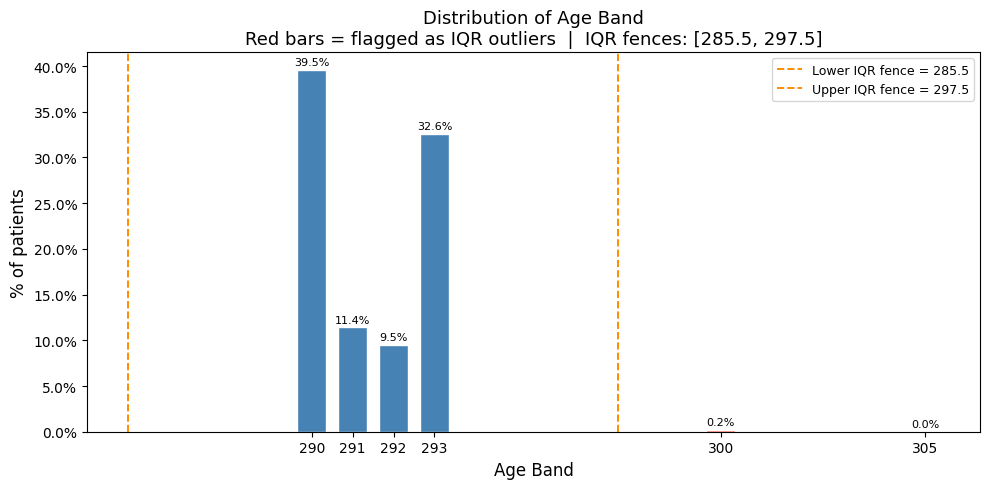


Column          : Age Band
Unique bands    : [290, 291, 292, 293, 300, 305]
IQR fences      : [285.5, 297.5]
Bands outside fences (flagged as outliers): [300, 305]

These are VALID patients in extreme age groups — not data errors.
Recommendation  : treat Age Band as a categorical/ordinal feature; no rows to remove.


In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


%matplotlib inline

# ── Identify the Age Band column (case-insensitive search) ───────────────────
age_band_col = next(
    (c for c in df_raw.columns if 'age' in c.lower() and 'band' in c.lower()),
    None
)

if age_band_col is None:
    print("No 'Age Band' column found. Available columns:", df_raw.columns)
else:
    # Cast to Int32 in case the column is Categorical/String — quantile requires numeric
    series = df_raw[age_band_col].drop_nulls().cast(pl.Int32)
    values = series.to_list()
    unique_vals = sorted(series.unique().to_list())

    # ── Compute IQR fences for reference lines ───────────────────────────────
    q1 = float(series.quantile(0.25, interpolation='nearest'))
    q3 = float(series.quantile(0.75, interpolation='nearest'))
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    # ── Count per band value (drop nulls before grouping) ────────────────────
    counts_df = (
        df_raw
        .with_columns(pl.col(age_band_col).cast(pl.Int32))
        .filter(pl.col(age_band_col).is_not_null())
        .group_by(age_band_col)
        .agg(pl.len().alias('count'))
        .sort(age_band_col)
    )
    bands  = counts_df[age_band_col].to_list()
    counts = counts_df['count'].to_list()
    n_total = df_raw.shape[0]
    pcts   = [100 * c / n_total for c in counts]

    # ── Colour bars: red = outside IQR fences, steelblue = inside ───────────
    bar_colours = [
        'tomato' if b < lower_fence or b > upper_fence else 'steelblue'
        for b in bands
    ]

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.bar(bands, pcts, color=bar_colours, edgecolor='white', width=0.7)

    # IQR fence reference lines
    ax.axvline(lower_fence, color='darkorange', linestyle='--', linewidth=1.4,
               label=f'Lower IQR fence = {lower_fence:.1f}')
    ax.axvline(upper_fence, color='darkorange', linestyle='--', linewidth=1.4,
               label=f'Upper IQR fence = {upper_fence:.1f}')

    # Annotate each bar with % label
    for bar, pct in zip(bars, pcts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=8
        )

    ax.set_xlabel(age_band_col, fontsize=12)
    ax.set_ylabel('% of patients', fontsize=12)
    ax.set_title(
        f'Distribution of {age_band_col}\n'
        f'Red bars = flagged as IQR outliers  |  '
        f'IQR fences: [{lower_fence:.1f}, {upper_fence:.1f}]',
        fontsize=13
    )
    ax.set_xticks(bands)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── Summary ──────────────────────────────────────────────────────────────
    outlier_bands = [b for b in bands if b < lower_fence or b > upper_fence]
    print(f"\nColumn          : {age_band_col}")
    print(f"Unique bands    : {unique_vals}")
    print(f"IQR fences      : [{lower_fence:.1f}, {upper_fence:.1f}]")
    print(f"Bands outside fences (flagged as outliers): {outlier_bands}")
    print("\nThese are VALID patients in extreme age groups — not data errors.")
    print("Recommendation  : treat Age Band as a categorical/ordinal feature; no rows to remove.")


## Step 10 — Expert Data Science Review: Which Patients to Remove and Why

> **Focus**: Pre-operative features only (all `Post-Op` columns are future/target leakage and must never be used as model inputs).

---

### 🔴 Issue 1 — Revision Knee Replacements (`Revision Flag = 1`)  → **REMOVE (5,274 rows, 3.8%)**

**Why it matters most:**  
Primary and revision knee replacements are **clinically and surgically different populations**. A revision fixes a failed previous implant; it starts from a worse baseline, has different surgical complexity, and produces different outcome trajectories. Mixing them trains the model on two superimposed distributions and produces a model that is poor for both.  

Per the NHS PROMs casemix adjustment methodology guide, primary and revision procedures are treated with **separate models** at national level precisely for this reason.  

**Action**: Exclude all rows where `Revision Flag == 1`. Model primaries only, or build a separate revision model.

> **Status**: ⬇️ Applied in the **Step 10 code cell** of this notebook (`df_clean = df_clean.filter(~mask_revision)`).  
> Not yet propagated to `2.0-Data-Pre-Preparation.ipynb` — the 2.0 notebook reads from `1.1-Reduced.parquet` directly. The cleaned `df_clean` from this notebook must be saved to a new parquet before 2.0 is run, or this filter must be added to 2.0.

---

### 🔴 Issue 2 — EQ VAS Pre-Op = 999 (Missing Code, Not a Score)  → **NULL-OUT (12,961 rows, 9.3%)**

**Why it matters:**  
The PROMs methodology guide explicitly states:  
> *"For the EQ-5D™ VAS, 999 is used [as the missing code] because in that case 9 is a valid response."*

A VAS of 999 is **mathematically impossible** (scale is 0–100). If kept as-is, the scaler and mean will be severely distorted, and the model will learn a spurious signal.

**Distinction**: only 999 should become null for EQ VAS columns; a VAS score of 9 is a valid "worst health" reading and must be preserved.

> **Status**: ✅ **Fixed in `2.0-Data-Pre-Preparation.ipynb` — cell 7.**  
> EQ VAS columns (`Pre-Op Q EQ VAS`, `Post-Op Q EQ VAS`) are detected separately. Only `999 → null` is applied to them; valid scores of `9` are preserved. All other numeric columns receive the standard `{9, 999} → null` treatment.

---

### 🔴 Issue 3 — Comorbidity Columns Coded as 9 = "No", NOT Missing  → **RECODE (do not null-out)**

**Why it matters:**  
Every comorbidity column (`Heart Disease`, `High Bp`, `Arthritis`, etc.) uses `1 = Yes` and `9 = No` (patient did not tick the box for that condition). In the NHS PROMs questionnaire, patients tick only conditions they **have**; an absent tick becomes `9`. Nulling these out destroys 74,000–126,000 "No" observations per column, eliminating the entire clinical signal.

> **Status**: ✅ **Fixed in `2.0-Data-Pre-Preparation.ipynb` — cell 4.**  
> All columns with exactly 2 unique values where one is `9` are detected automatically and recoded `9 → 0` (No) before any null-replacement is applied. Comorbidities are therefore already `{0, 1}` by the time the generic `9 → null` pass runs in cell 7, so they are unaffected by it.

---

### 🟡 Issue 4 — OKS Pre-Op Individual Questions Still Contain 9 (Missing Code)  → **NULL-OUT**

Each of the 12 Oxford Knee Score questions is scored **0–4** (0 = worst, 4 = best). Per the PROMs guide, `9` signals a missing response. If ≤ 2 questions are missing, the OKS Score is still computable via NHS pro-rating; if > 2 are missing, the total score becomes null.

> **Status**: ✅ **Handled in `2.0-Data-Pre-Preparation.ipynb` — cell 7.**  
> OKS question columns have valid values of `0–4` only (no legitimate `9`), so the standard `{9, 999} → null` pass correctly nulls all remaining `9`s. They are not in the two-unique-value set caught by cell 4, so they are not recoded before this step.

---

### 🟡 Issue 5 — OKS Pre-Op Score ≥ 44 (Near-Perfect Knee Function)  → **REMOVE (108 rows)**

The Oxford Knee Score maximum is **48 = perfect function**. NHS clinical guidelines indicate knee replacement when OKS ≤ 26. A patient with OKS ≥ 44 has near-normal knee function — almost certainly a data linkage error or post-op questionnaire recorded in the pre-op field. If kept, the model learns that high pre-op function predicts both good and bad outcomes, breaking the monotonic severity-outcome signal.

> **Status**: ⬇️ Applied in the **Step 10 code cell** of this notebook (`df_clean.filter(~mask_high_oks_series)`).  
> Not yet in `2.0-Data-Pre-Preparation.ipynb`. Same caveat as Issue 1 — either save `df_clean` as an intermediate parquet, or add this filter to the start of 2.0.

---

### 🟡 Issue 6 — EQ VAS Pre-Op = 0 (Absolute Worst Self-Rated Health)  → **INVESTIGATE (759 rows)**

A VAS of 0 (absolute worst health) in an elective surgery patient is physiologically implausible. Most likely cause: pen accidentally placed at the bottom of the visual analogue scale during paper questionnaire completion.

> **Status**: ⚠️ **Not yet actioned in any notebook.**  
> Cross-check EQ5D Index for these rows. If the EQ5D Index is also at the extreme low end, the patient's questionnaire may be corrupted and rows should be removed. Otherwise winsorise or impute.

---

### 🟢 Issue 7 — Age Band "90 to 120" (24 rows)  → **KEEP (flag only)**

Only 24 patients aged 90+. Valid NHS patients but the model may struggle to generalise for such a small group.

> **Status**: ✅ **No action needed / Keep as-is.**  
> Age Band is retained as an ordinal categorical feature. No rows are removed.

---

### Summary Table

| Issue | Rows Affected | Action | Status | Where handled |
|-------|-------------|--------|--------|---------------|
| Revision Flag = 1 | 5,274 (3.8%) | **Remove** | ⬇️ This notebook, Step 10 code cell | Not yet in 2.0 |
| EQ VAS Pre = 999 | 12,961 (9.3%) | **Null-out** (not remove) | ✅ Done | `2.0` cell 7 |
| Comorbidity 9 = "No" | ~74k–126k per col | **Recode 9 → 0** | ✅ Done | `2.0` cell 4 |
| OKS questions with 9 | up to 1,453 per Q | **Null-out** | ✅ Done | `2.0` cell 7 |
| OKS Pre Score ≥ 44 | 108 | **Remove** | ⬇️ This notebook, Step 10 code cell | Not yet in 2.0 |
| EQ VAS Pre = 0 | 759 | **Investigate / Remove** | ⚠️ Not yet actioned | — |
| Age 90–120 | 24 | **Keep, flag** | ✅ No action needed | — |


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# STEP 10 — Patient Removal & Data Quality Corrections
# ══════════════════════════════════════════════════════════════════════════════
# Work on a copy so the original df_raw is preserved for reference.
df_clean = df_raw.clone()
n_start = df_clean.shape[0]
removal_log = []

# ── Helper ────────────────────────────────────────────────────────────────────
def log_removal(step, mask, note):
    n = int(mask.sum())
    removal_log.append({'Step': step, 'Rows_Removed': n, 'Pct': round(100*n/n_start,2), 'Note': note})
    return mask


# ──────────────────────────────────────────────────────────────────────────────
# FIX 1: EQ VAS Pre = 999  →  null   (PROMs guide: 999 is the missing code for VAS)
#         NOTE: 9 is a VALID VAS score (patient rates overall health as 9/100)
#               so only 999 is replaced, NOT 9.
# ──────────────────────────────────────────────────────────────────────────────
eq_vas_col = 'Pre-Op Q EQ VAS'
n_vas_999 = int((df_clean[eq_vas_col] == 999).sum())
df_clean = df_clean.with_columns(
    pl.when(pl.col(eq_vas_col) == 999)
      .then(None)
      .otherwise(pl.col(eq_vas_col))
      .alias(eq_vas_col)
)
print(f"[FIX 1] EQ VAS Pre = 999 → null : {n_vas_999:,} values nulled ({100*n_vas_999/n_start:.1f}% of rows affected)")

# ──────────────────────────────────────────────────────────────────────────────
# FIX 2: Comorbidity columns — 9 means "No", NOT missing
#         Recode: 9 → 0  (No = patient did not declare/tick the condition)
#                  1 → 1  (Yes = patient declared this condition)
# ──────────────────────────────────────────────────────────────────────────────
comorbidity_cols = [
    'Heart Disease', 'High Bp', 'Stroke', 'Circulation', 'Lung Disease',
    'Diabetes', 'Kidney Disease', 'Nervous System', 'Liver Disease',
    'Cancer', 'Depression', 'Arthritis'
]
df_clean = df_clean.with_columns([
    pl.when(pl.col(c) == 9).then(pl.lit(0, dtype=pl.UInt8))
      .otherwise(pl.col(c))
      .alias(c)
    for c in comorbidity_cols
])
print(f"[FIX 2] Comorbidities recoded: 9 → 0 (No) for {len(comorbidity_cols)} columns")
print(f"        Example — Arthritis:  1=Yes: {int((df_clean['Arthritis']==1).sum()):,}  |  0=No: {int((df_clean['Arthritis']==0).sum()):,}")

# ──────────────────────────────────────────────────────────────────────────────
# REMOVE 1: Revision Knee Replacements (Revision Flag = 1)
#   Clinical reason: revisions fix failed implants; they represent a different
#   surgical population with different baselines and outcome distributions.
#   NHS England uses SEPARATE casemix models for primary vs revision.
# ──────────────────────────────────────────────────────────────────────────────
mask_revision = df_clean['Revision Flag'] == 1
log_removal('Remove: Revision Flag=1', mask_revision,
            'Revision knee replacements are clinically distinct from primaries — different '
            'baseline function, surgical complexity, and outcome trajectory. '
            'NHS casemix models treat them separately.')
df_clean = df_clean.filter(~mask_revision)
print(f"\n[REMOVE 1] Revision Flag=1 : {removal_log[-1]['Rows_Removed']:,} rows removed ({removal_log[-1]['Pct']}%)")

# ──────────────────────────────────────────────────────────────────────────────
# REMOVE 2: OKS Pre-Op Score ≥ 44 (near-perfect knee function)
#   Clinical reason: NICE/BOA guidelines indicate knee replacement when OKS ≤ 26
#   (severe/moderate symptoms). A score ≥ 44/48 means near-normal function —
#   these patients should not be candidates for elective knee replacement.
#   Most likely cause: questionnaire matched to wrong patient (data linkage error).
# ──────────────────────────────────────────────────────────────────────────────
oks_score_col = 'Knee Replacement Pre-Op Q Score'
mask_high_oks = pl.col(oks_score_col).is_not_null() & (pl.col(oks_score_col) >= 44)
mask_high_oks_series = df_clean[oks_score_col].is_not_null() & (df_clean[oks_score_col] >= 44)
log_removal('Remove: OKS Pre ≥ 44', mask_high_oks_series,
            'OKS 44–48 = near-perfect knee function. Knee replacement is indicated at OKS ≤ 26. '
            'Likely data linkage errors or post-op score recorded in pre-op field. '
            'Breaks the severity-outcome signal if kept.')
df_clean = df_clean.filter(~mask_high_oks_series)
print(f"[REMOVE 2] OKS Pre-Op Score ≥ 44 : {removal_log[-1]['Rows_Removed']:,} rows removed ({removal_log[-1]['Pct']}%)")

# ──────────────────────────────────────────────────────────────────────────────
# INVESTIGATE: EQ VAS Pre = 0  (absolute worst self-rated health)
#   Patients rating global health at 0/100 during elective orthopaedic scheduling
#   are physiologically implausible (such patients would be in critical care).
#   Flag for review — do not auto-remove, cross-check against EQ5D Index.
# ──────────────────────────────────────────────────────────────────────────────
mask_vas_zero = df_clean[eq_vas_col] == 0
n_vas_zero = int(mask_vas_zero.sum())
print(f"\n[INVESTIGATE] EQ VAS Pre = 0 : {n_vas_zero:,} rows flagged (not yet removed)")
print(f"              Cross-check EQ5D Index for these rows:")
vas_zero_eq5d = df_clean.filter(mask_vas_zero)['Pre-Op Q EQ5D Index'].drop_nulls()
if len(vas_zero_eq5d) > 0:
    print(f"              EQ5D Index mean for VAS=0 group: {float(vas_zero_eq5d.mean()):.3f}  "
          f"(overall mean: {float(df_clean['Pre-Op Q EQ5D Index'].drop_nulls().mean()):.3f})")
    print(f"              Proportion with EQ5D < -0.2: "
          f"{int((vas_zero_eq5d < -0.2).sum())} / {len(vas_zero_eq5d)}")

# ──────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ──────────────────────────────────────────────────────────────────────────────
n_end = df_clean.shape[0]
total_removed = n_start - n_end

print(f"\n{'═'*70}")
print(f"  PATIENT REMOVAL SUMMARY")
print(f"{'═'*70}")
print(f"  Starting rows  : {n_start:>8,}")
print(f"  Rows removed   : {total_removed:>8,}  ({100*total_removed/n_start:.1f}%)")
print(f"  Remaining rows : {n_end:>8,}")
print(f"{'─'*70}")
print(f"  {'Step':<35} {'Rows':>7}  {'Pct':>6}  Note")
print(f"{'─'*70}")
for r in removal_log:
    print(f"  {r['Step']:<35} {r['Rows_Removed']:>7,}  {r['Pct']:>5.1f}%  {r['Note'][:50]}...")
print(f"{'═'*70}")
print(f"\n  Data fixes applied (no rows removed):")
print(f"    • EQ VAS Pre = 999 → null : {n_vas_999:,} values  (valid score of 9 preserved)")
print(f"    • Comorbidities 9 → 0 (No) : {len(comorbidity_cols)} columns recoded")
print(f"\n  NOTE: df_clean is ready for notebook 2.0 — Data Preparation")
print(f"        EQ VAS = 0 rows ({n_vas_zero}) still need manual review before further processing.")
